In [1]:
# reload modules before execution (for the changing code in src)
%load_ext autoreload
%autoreload 2

In [74]:
import pandas as pd

from pathlib import Path
import sys

import matplotlib.pyplot as plt

import plotly.express as px
import plotly.io as pio
pio.renderers.default = "iframe"

sys.path.append(str(Path.cwd().parent))
import src.utils as utils

countries_db_name = '../data/processed/countries.db'
findex_db_name = '../data/raw/Findex.db'
sql_folder = '../sql/'

## What percentage of people pay bills worldwide?

### fin30 "Made a utility payment, total (% age 15+)"

In [43]:
# import data from the database
fin30_tuples = utils.run_sql(countries_db_name, sql_folder + 'fin30.sql')
fin30_data = pd.DataFrame(fin30_tuples, columns = ['country_id', 'wave', 'perc_val'])
# observation for 2021 wave were gathered in 2021 and 2022
# make observations representative of the wave
fin30_data['wave'] = fin30_data['wave'].astype(int)
fin30_data.loc[fin30_data['wave'] == 2022, 'wave'] = 2021

In [57]:
'''
TODO there's a way to make sublopt like pic
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np
rows = 2
cols = 2
waves = [2014, 2017, 2021, 2024]
fig = make_subplots(rows=rows, cols=cols, 
 specs = [[{'type': 'choropleth'} for c in np.arange(cols)] for r in np.arange(rows)],
 subplot_titles = waves, vertical_spacing=0.1, horizontal_spacing=0)

for i, y in enumerate(waves):
    wave_data = fin30_data[fin30_data['wave'] == y]
    fig.add_trace(go.Choropleth(locations=wave_data['country_id'], z = wave_data['perc_val'], locationmode = 'ISO-3', row = i//cols+1, col = i%cols+1))
    fig.update_layout(title={'text':'Religious Tradition by Year', 'xanchor': 'center','x':0.5}, **{'geo' + str(i) + '_scope': 'usa' for i in [''] + np.arange(2,rows*cols+1).tolist()},
 coloraxis_showscale=False, margin={"r":10,"t":70,"l":10,"b":0},
 hoverlabel=dict(bgcolor='#e6e6e6', font_size=12, font_family="Rockwell"))
'''

'\nTODO there\'s a way to make sublopt like pic\nfrom plotly.subplots import make_subplots\nimport plotly.graph_objects as go\nimport numpy as np\nrows = 2\ncols = 2\nwaves = [2014, 2017, 2021, 2024]\nfig = make_subplots(rows=rows, cols=cols, \n specs = [[{\'type\': \'choropleth\'} for c in np.arange(cols)] for r in np.arange(rows)],\n subplot_titles = waves, vertical_spacing=0.1, horizontal_spacing=0)\n\nfor i, y in enumerate(waves):\n    wave_data = fin30_data[fin30_data[\'wave\'] == y]\n    fig.add_trace(go.Choropleth(locations=wave_data[\'country_id\'], z = wave_data[\'perc_val\'], locationmode = \'ISO-3\', row = i//cols+1, col = i%cols+1))\n    fig.update_layout(title={\'text\':\'Religious Tradition by Year\', \'xanchor\': \'center\',\'x\':0.5}, **{\'geo\' + str(i) + \'_scope\': \'usa\' for i in [\'\'] + np.arange(2,rows*cols+1).tolist()},\n coloraxis_showscale=False, margin={"r":10,"t":70,"l":10,"b":0},\n hoverlabel=dict(bgcolor=\'#e6e6e6\', font_size=12, font_family="Rockwell"))

In [58]:
wave = 2021
temp = fin30_data[fin30_data['wave'] == wave]
fig = px.choropleth(
temp,
locations="country_id",          # column with ISO-3 country codes, e.g. POL, AUS
color="perc_val",                # numeric column to color by
#hover_name="country_name",    # optional
color_continuous_scale="Inferno",
projection="natural earth",
#projection = 'miller',
title=f"% of population paying utility bills in {wave}"
)
fig.show()

### Additional info for people who pay bills exploration

In [59]:
# paired observation values, for additional info and base series for (country, date)
# fin31.* series with additional info pair
# fin31.* is "Made utility payment..."
fin31_paired_info_tuples = utils.run_sql(countries_db_name, sql_folder + 'paired_additional_info.sql')
fin31_paired_data = pd.DataFrame(fin31_paired_info_tuples, columns = ['country_id', 'observation_date', 's_id', 's_val', 'base_id', 'base_val'])

# sanity check loaded fin31 group series paired data
assert not fin31_paired_data.empty, (
    f"No data imported from {countreis_db_name}"
)

# sanity check paired fin31 data completeness
assert fin31_paired_data.notna().all().all()

In [60]:
# check if no denominator 0s present
assert not (fin31_paired_data['s_val'] == 0).all(), (
    f"Division by 0 about to happen."
)

# calculate latent values 'ratio of people who payed utility bills'
# using conditional probability
fin31_paired_data['latent'] = fin31_paired_data['base_val']/fin31_paired_data['s_val']

In [61]:
# recover latent values per (country, wave)
fin31_latent = fin31_paired_data[['country_id', 'observation_date', 'latent']].copy()
# convert latent from float ratio to in percent
fin31_latent['latent'] = (fin31_latent['latent'].round(2) * 100).astype(int)
# trim observation date to meaningful year
fin31_latent['observation_date'] = fin31_latent['observation_date'].str.slice(stop = 4)
fin31_latent['observation_date'] = pd.to_numeric(fin31_latent['observation_date'])
# recover unique values per (country, year)
fin31_latent.drop_duplicates(inplace = True)

To be sure, validation is performed: same data is queried from database available at data360 interface from World Bank.
The most important check is the spread.
If assumptions of ability to recover latent data using conditional probability formulas are correct, one should observe 0 spreads per (country, wave) throughout relevant series, where spread is max difference between latent values per (country, wave).

In [62]:
fin31_check_data_tuples = utils.run_sql(findex_db_name, sql_folder + 'fin31_latent.sql')
fin31_check_data = pd.DataFrame(fin31_check_data_tuples, columns = ['country_id', 'wave', 'latent', 'spread'])
# convert year to a numeric
fin31_check_data['wave'] = pd.to_numeric(fin31_check_data['wave'])
# round spread to 10 decimal places
# to account for floating point arithmetic in DB
# and to reflect tolerance for difference < 1e-10
fin31_check_data['spread'] = fin31_check_data['spread'].round(10)
# convert latent to integer percentages
fin31_check_data['latent'] = (fin31_check_data['latent'].round(2) * 100).astype(int)

In [63]:
# all spreads should be 0
gt0_spread_no = (fin31_check_data['spread'] > 0).sum()

assert gt0_spread_no == 0, (
    f"Expected all spreads to be 0, but found {gt0_spread_no} spreads > 0."
)

In [64]:
# data between databases should be equal
temp = pd.merge(fin31_check_data, fin31_latent, left_on = ['country_id', 'wave'], right_on = ['country_id', 'observation_date'])
different_no = (temp['latent_x'] != temp['latent_y']).sum()
assert different_no == 0, (
    f"Got {different_no} differences in data."
)

In [65]:
# 2021 wave survey was conducted in 2021 and 2022.
# Change 2022 to 2021 to reflect observations coming from one wave
fin31_latent.loc[fin31_latent['observation_date'] == 2022, 'observation_date'] = 2021

In [66]:
# 2011 wave has no latent values available
# waves = [2014, 2017, 2021, 2024]
waves = [2021]

In [67]:
wave_mask = {}
for wave in waves:
    wave_mask[wave] = fin31_latent['observation_date'] == wave
    wave_data = fin31_latent[wave_mask[wave]]
    
    print(wave)
    fig = px.choropleth(
    wave_data,
    locations="country_id",          # column with ISO-3 country codes, e.g. POL, AUS
    color="latent",                # numeric column to color by
    #hover_name="country_name",    # optional
    color_continuous_scale="Inferno",
    projection="natural earth",
    #projection = 'miller',
    title=f"% of population paying utility bills in {wave}"
    )
    fig.show()

2021


### Compare two results

In [71]:
waves = [2014, 2017, 2021, 2024]

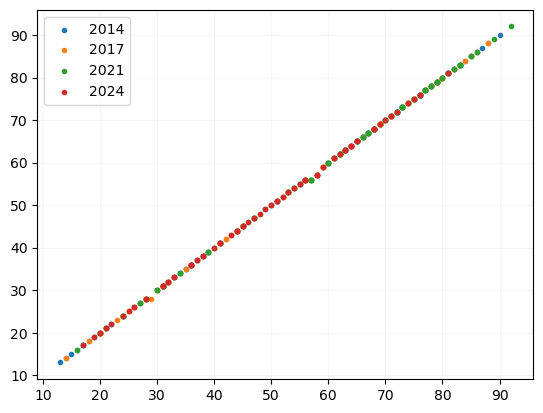

In [92]:
# investigation of values existing in both data frames
for wave in waves:
    fin30_wave_data = fin30_data[fin30_data['wave'] == wave]
    fin31_wave_latent = fin31_latent[fin31_latent['observation_date'] == wave]

    # combine latent value according to country
    scatter_data = pd.DataFrame()
    scatter_data = pd.merge(
    fin30_wave_data,
    fin31_wave_latent,
    on='country_id',
    how='outer'
    )
    scatter_data.dropna(inplace = True)

    plt.scatter(scatter_data['perc_val'], scatter_data['latent'], marker = '.', label = wave)

plt.grid(True, alpha = 0.1)
plt.legend()
plt.show()
# TODO 1% scatter band
# TODO no of observations included in each wave in the legend

In [ ]:
# TODO rows countries, columns waves, both available, only inferred, only in db, neither heatmap/tile map

In [ ]:
# Histogram of official - inferred